# Tool binding

Tool Binding ka matlab hai LLM ko tools ke saath connect karna, taaki LLM zarurat padne par tool call kar sake.

# Simple words me:

Tool Binding = LLM + Tools

# Without binding:

LLM

LLM sirf text generate karega.

With binding:

LLM + Tools

LLM decide kar sakta hai:

Kaunsa tool use karna hai

Kab use karna hai

Kya input dena hai

# Why Tool Binding?

Maan lo tumhare paas ek tool hai:

@tool

def multiply(a: int, b: int):

    return a * b

# Agar tool bind nahi hai:

User → What is 5 × 8?
LLM → Guess answer

# Agar tool bind hai:

User
 ↓
LLM
 ↓
Multiply Tool
 ↓
40
 ↓
LLM
 ↓
Answer

# Example



In [ ]:
# Create Tool
from langchain.tools import tool

@tool
def multiply(a: int, b: int):
    """Multiply two numbers"""
    return a * b

In [ ]:
# Bind Tool to LLM
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

llm_with_tools = llm.bind_tools([multiply])

In [ ]:
# Multiple Tool Binding
llm_with_tools = llm.bind_tools([
    multiply,
    get_weather,
    search_tool
])

# Architecture:

                LLM
                 │
      ┌──────────┼──────────┐
      │          │          │
 Multiply   Weather    Search
   Tool       Tool       Tool

# Tool Binding in Agent Ecosystem


In [ ]:
                    Agent
                       │
                  Uses LLM
                       │
                 Bound Tools
                       │
      ┌────────────────┼───────────────┐
      │                │               │
 Calculator      Weather Tool     Search Tool

# Tool Binding is the process of attaching one or more tools to an LLM so that the model can generate structured tool calls and invoke external functionality when required.

# Tool Calling

LLM ka directly kisi tool ko “structured format me request bhejna” taaki wo external action execute ho sake.

# Simple words me:

Tool Calling = LLM → JSON format me tool ko call karta hai

# Basic Idea

Agar user bole:

"What is 25 × 12?"

LLM sirf guess nahi karega.

Instead it will:

Call multiply tool

# Tool Calling Flow
User
 ↓
LLM (with tools)
 ↓
Tool Call (structured JSON)
 ↓
Tool Execution
 ↓
Result
 ↓
LLM Final Answer


# Example



In [ ]:
# Step 1: Tool define karo
from langchain.tools import tool

@tool
def multiply(a: int, b: int):
    """Multiply two numbers"""
    return a * b

In [ ]:
# Step 2: Tool bind karo LLM ke saath
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

llm_with_tools = llm.bind_tools([multiply])

In [ ]:
# Step 3: Tool Calling happen hota hai

User:

What is 25 × 12?

LLM output (Tool Call JSON):

{
  "tool_calls": [
    {
      "name": "multiply",
      "arguments": {
        "a": 25,
        "b": 12
      }
    }
  ]
}

👉 Yehi Tool Calling hai.

In [ ]:
# Step 4: Tool execute hota hai
multiply(25, 12) → 300

In [ ]:
# Step 5: Final Answer
The answer is 300.

* Correct Concept

# 👉 LLM tool ko directly execute nahi karta
# 👉 LLM sirf tool call suggest/generate karta hai (with arguments)
# 👉 Actual execution LangChain runtime / agent executor karta hai

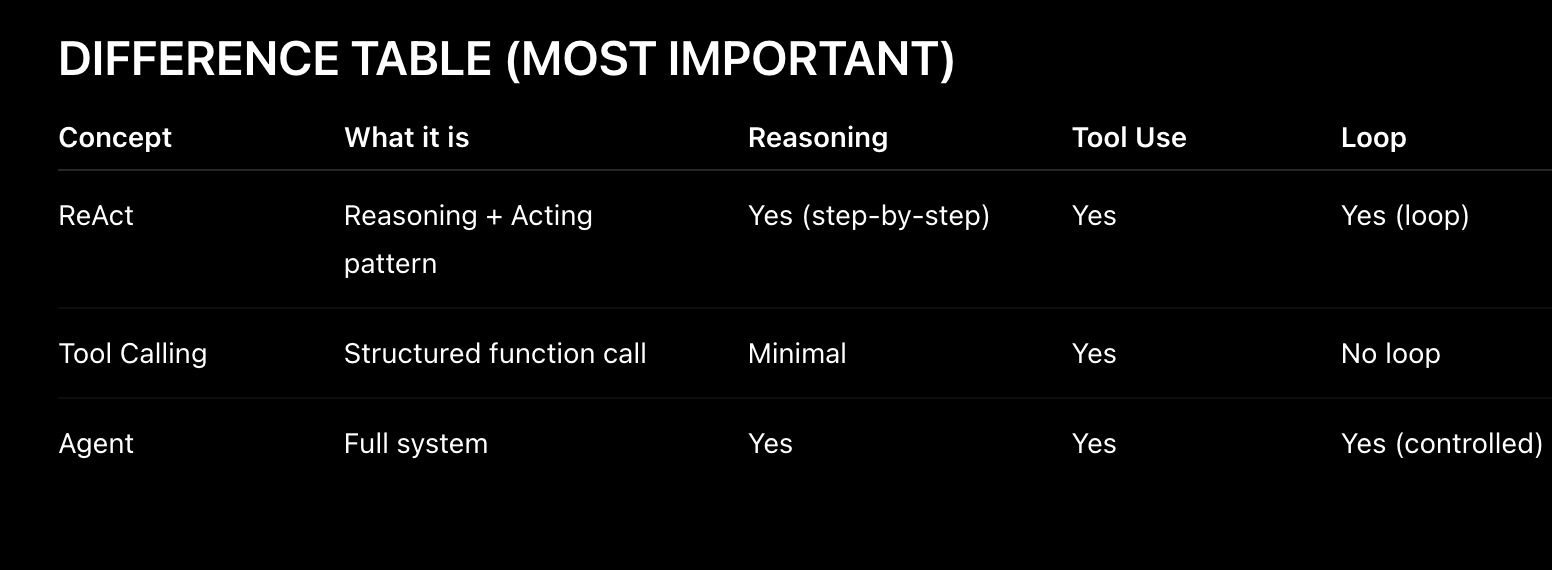

# Tool Execution

jab LLM ne tool call kar diya, us tool ka actual function run hona.

Simple words me:

Tool Execution = real code/API/function ka execute hona



In [ ]:
# Full Flow (Important)

User
 ↓
LLM (Tool Call generate karta hai)
 ↓
Tool Execution (actual function runs)
 ↓
Observation (result milta hai)
 ↓
LLM final answer generate karta hai

# Example

In [ ]:
# Step 1: Tool Define
from langchain.tools import tool

@tool
def multiply(a: int, b: int):
    return a * b


In [ ]:
# Step 2: Tool Call (LLM output)

LLM ne decide kiya:

{
  "name": "multiply",
  "arguments": {
    "a": 25,
    "b": 12
  }
}

👉 Ye sirf request hai, abhi result nahi aaya.

In [ ]:
 #Step 3: Tool Execution (REAL STEP)

LangChain ab function run karega:

multiply(25, 12)

Output:

300

👉 Ye hi Tool Execution hai.

In [ ]:
# Real Agent Flow
User: 25 × 12 kya hai?

LLM:
  ↓
Tool Call → multiply(a=25, b=12)

LangChain:
  ↓
Tool Execution → multiply(25,12)

Result:
  ↓
300

LLM:
  ↓
Final Answer: 300

# Code

In [1]:
!pip install -q langchain-openai langchain-core requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 8.3 MB/s eta 0:00:00


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

In [3]:
# tool create

@tool
def multiply(a: int, b: int) -> int:
  """Given 2 numbers a and b this tool returns their product"""
  return a * b

In [ ]:
print(multiply.invoke({'a':3, 'b':4}))

In [ ]:
multiply.name

In [ ]:
multiply.description

In [ ]:
multiply.args

In [ ]:
# tool binding

In [ ]:
llm = ChatOpenAI()

In [ ]:
llm.invoke('hi')

In [ ]:
llm_with_tools = llm.bind_tools([multiply])

In [ ]:
llm_with_tools.invoke('Hi how are you')

In [ ]:
query = HumanMessage('can you multiply 3 with 1000')

In [ ]:
messages = [query]

In [ ]:
messages

In [ ]:
result = llm_with_tools.invoke(messages)

In [ ]:
messages.append(result)

In [ ]:
messages

In [ ]:
tool_result = multiply.invoke(result.tool_calls[0])

In [ ]:
tool_result


In [ ]:
messages.append(tool_result)

In [ ]:
llm_with_tools.invoke(messages).content

In [ ]:
# tool create
from langchain_core.tools import InjectedToolArg
from typing import Annotated

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency and a target currency
  """
  url = f'https://v6.exchangerate-api.com/v6/c754eab14ffab33112e380ca/pair/{base_currency}/{target_currency}'

  response = requests.get(url)

  return response.json()

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg]) -> float:
  """
  given a currency conversion rate this function calculates the target currency value from a given base currency value
  """

  return base_currency_value * conversion_rate

In [ ]:
convert.args

In [ ]:
get_conversion_factor.invoke({'base_currency':'USD','target_currency':'INR'})

In [ ]:
convert.invoke({'base_currency_value':10, 'conversion_rate':85.16})

In [ ]:
# tool binding
llm = ChatOpenAI()

In [ ]:
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])

In [ ]:
messages = [HumanMessage('What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd')]

In [ ]:
messages

In [ ]:
ai_message = llm_with_tools.invoke(messages)

In [ ]:
messages.append(ai_message)

In [ ]:
ai_message.tool_calls

In [ ]:
import json

for tool_call in ai_message.tool_calls:
  # execute the 1st tool and get the value of conversion rate
  if tool_call['name'] == 'get_conversion_factor':
    tool_message1 = get_conversion_factor.invoke(tool_call)
    # fetch this conversion rate
    conversion_rate = json.loads(tool_message1.content)['conversion_rate']
    # append this tool message to messages list
    messages.append(tool_message1)
  # execute the 2nd tool using the conversion rate from tool 1
  if tool_call['name'] == 'convert':
    # fetch the current arg
    tool_call['args']['conversion_rate'] = conversion_rate
    tool_message2 = convert.invoke(tool_call)
    messages.append(tool_message2)


In [ ]:
messagesllm_with_tools.invoke(messages).content

In [ ]:
from langchain.agents import initialize_agent, AgentType

# Step 5: Initialize the Agent ---
agent_executor = initialize_agent(
    tools=[get_conversion_factor, convert],
    llm=llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,  # using ReAct pattern
    verbose=True  # shows internal thinking
)

In [ ]:
# --- Step 6: Run the Agent ---
user_query = "Hi how are you?"

response = agent_executor.invoke({"input": user_query})

# Is this is ai agent ?

Yes — but not always. Let’s make it precise.

What is an AI Agent?

An AI agent is a system that:

1. Understands user input
2. Decides what to do
3. Can use tools
4. Can take multiple steps
5. Produces final answer

#Simple Definition

👉 AI Agent = LLM + Tools + Decision-making loop

# So is Tool Calling an AI Agent?
❌ Not by itself

Tool calling alone is just:

LLM → gives tool + arguments (JSON)

It does NOT:

Decide multiple steps

Run reasoning loop

Plan actions

So tool calling ≠ full agent

# When does it become an AI Agent?

When you add:

✔ Tool selection

✔ Execution loop

✔ Multi-step reasoning

✔ (optional) memory

Then it becomes:

👉 AI Agent

# 👉 Yes, this becomes an AI agent only when the system can autonomously decide, reason, and use tools in multiple steps — not just generate a single tool call.